In [1]:
# install ISLP

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
from ISLP import load_data

In [3]:
# Load the Boston dataset
boston = load_data("Boston")

# Define features (X) and target (y)
X = boston.drop(columns='medv')
y = boston['medv']

In [4]:
# Standardize the features (as PCR expects standardized data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=8)


In [5]:
# Fit the LARS model
from sklearn.linear_model import LarsCV

In [6]:
# Perform LARS with cross-validation
lars_cv_model = LarsCV(cv=5)  # 5-fold cross-validation
lars_cv_model.fit(X_train, y_train)

# Predict on the test set
y_pred = lars_cv_model.predict(X_test)

# Calculate the MSE on the test set
mse = mean_squared_error(y_test, y_pred)
print(f"LARS with Cross-Validation MSE on test set: {mse}")

# Print the selected features
print("Selected Features and Coefficients:")
for feature, coef in zip(X.columns, lars_cv_model.coef_):
    if coef != 0:
        print(f"{feature}: {coef}")

LARS with Cross-Validation MSE on test set: 26.595657949386172
Selected Features and Coefficients:
crim: -1.2031575680459483
zn: 1.7953320676266993
indus: 0.03282689832386996
chas: 0.5284130216091729
nox: -1.4689102833169376
rm: 2.0559146497231753
age: -0.10103822422246136
dis: -3.2735347701310964
rad: 2.4475620823414252
tax: -1.9064365758772093
ptratio: -2.160766434648045
lstat: -4.523774530848714


In [7]:
### Cross-validation to select the optimal number of components for PCR
mse_values = []  # Store the MSE for each number of components
for n_components in range(1, X_train.shape[1] + 1):
    # Perform PCA
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)

    # Fit Linear Regression model on the principal components
    pcr_model = LinearRegression()

    # Perform 5-fold cross-validation and calculate the MSE
    mse = -np.mean(cross_val_score(pcr_model, X_train_pca, y_train, scoring='neg_mean_squared_error', cv=5))
    mse_values.append(mse)


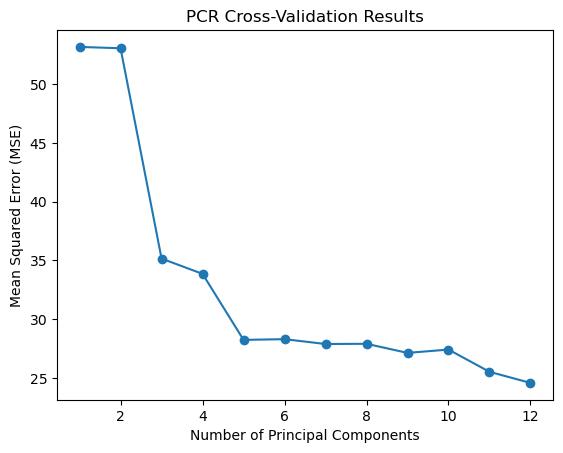

In [8]:
# Plot the results
plt.plot(range(1, X_train.shape[1] + 1), mse_values, marker='o')

plt.xlabel('Number of Principal Components')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('PCR Cross-Validation Results')
plt.show()

In [9]:
# Find the optimal number of principal components (minimizing MSE)
best_n_components_pcr = np.argmin(mse_values) + 1
print(f"Optimal number of principal components for PCR: {best_n_components_pcr}")


Optimal number of principal components for PCR: 12


In [10]:
### Refit PCR model using the optimal number of components on the full training set
# Apply PCA with the optimal number of components
pca = PCA(n_components=best_n_components_pcr)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [11]:
# Fit the PCR model (Linear Regression on the principal components)
pcr_model = LinearRegression()
pcr_model.fit(X_train_pca, y_train)

# Make predictions on the test set
pcr_pred = pcr_model.predict(X_test_pca)
# Calculate the MSE on the test set
pcr_mse = mean_squared_error(y_test, pcr_pred)
print(f"PCR MSE on test set with {best_n_components_pcr} components: {pcr_mse}")


PCR MSE on test set with 12 components: 26.757984901548312


Example on the Hitters dataset

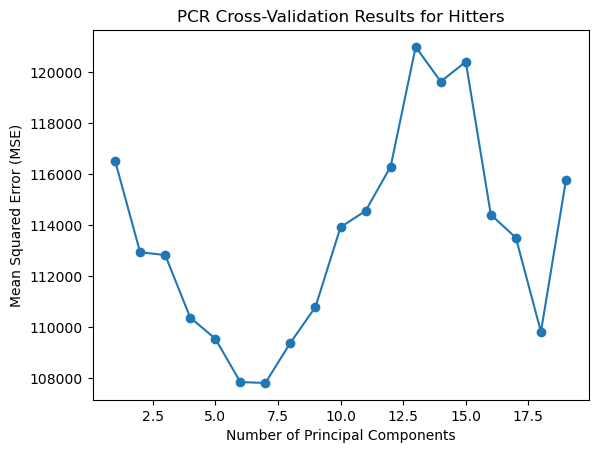

Optimal number of principal components for PCR: 7
PCR MSE on test set with 7 components: 149620.18424437926


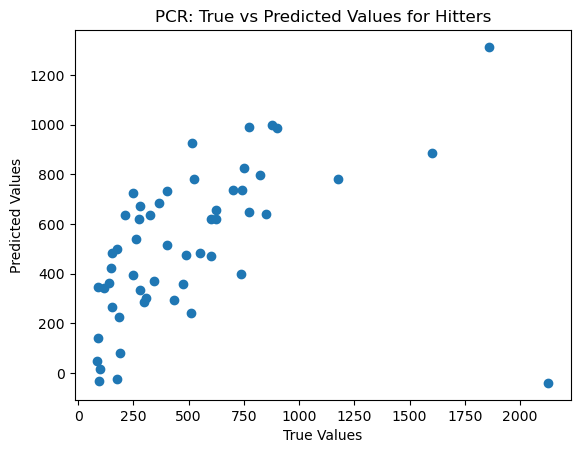

In [12]:
# Load the Hitters dataset
hitters = load_data("Hitters")

# Drop missing values
hitters = hitters.dropna()

# Define features (X) and target (y)
X = hitters.drop(columns='Salary')
y = hitters['Salary']

# One-hot encode categorical variables (necessary for non-numeric data)
X = pd.get_dummies(X, drop_first=True)

# Standardize the features (as PCR expects standardized data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Cross-validation to select the optimal number of components for PCR
mse_values = []  # Store the MSE for each number of components

# Perform cross-validation for different numbers of components
for n_components in range(1, X_train.shape[1] + 1):
    # Perform PCA
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)

    # Fit Linear Regression model on the principal components
    pcr_model = LinearRegression()

    # Perform 10-fold cross-validation and calculate the MSE
    mse = -np.mean(cross_val_score(pcr_model, X_train_pca, y_train, scoring='neg_mean_squared_error', cv=10))
    mse_values.append(mse)

# Ensure mse_values contains the same number of elements as the number of components tested
n_components_tested = len(mse_values)

# Plot the cross-validation results to visualize the best number of components
plt.plot(range(1, n_components_tested + 1), mse_values, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('PCR Cross-Validation Results for Hitters')
plt.show()

# Find the optimal number of principal components (minimizing MSE)
best_n_components_pcr = np.argmin(mse_values) + 1
print(f"Optimal number of principal components for PCR: {best_n_components_pcr}")

### Refit PCR model using the optimal number of components on the full training set
# Apply PCA with the optimal number of components
pca = PCA(n_components=best_n_components_pcr)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Fit the PCR model (Linear Regression on the principal components)
pcr_model = LinearRegression()
pcr_model.fit(X_train_pca, y_train)

# Make predictions on the test set
pcr_pred = pcr_model.predict(X_test_pca)

# Calculate the MSE on the test set
pcr_mse = mean_squared_error(y_test, pcr_pred)
print(f"PCR MSE on test set with {best_n_components_pcr} components: {pcr_mse}")

# Plot the actual vs predicted values for the PCR model
plt.scatter(y_test, pcr_pred)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('PCR: True vs Predicted Values for Hitters')
plt.show()
